## EXP 11 - Implementation-of-K-Means-Clustering-for-Customer-Segmentation
## Name : HARISHBALA J ##
## Register Number : 212224223002 ##

Dataset Preview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


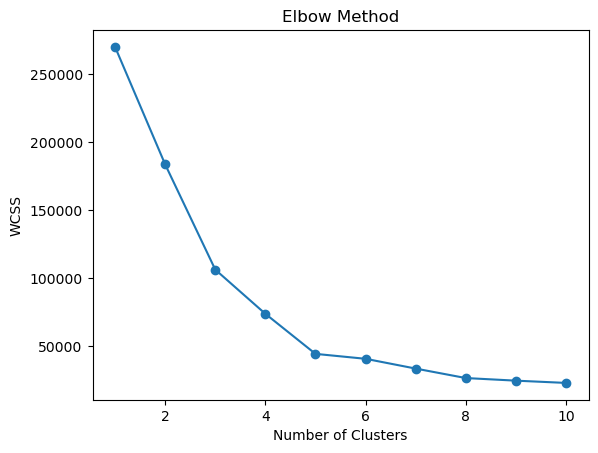


Clustered Data:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


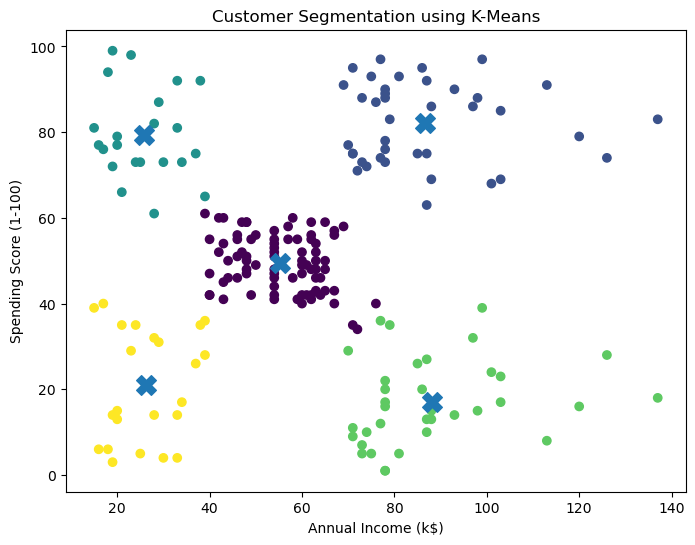

In [1]:

# K-Means Clustering for Customer Segmentation

# Import required libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
data = pd.read_csv("Mall_Customers.csv")

# Display dataset
print("Dataset Preview:")
print(data.head())

# Select features for clustering
# Annual Income and Spending Score
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Finding the optimal number of clusters using Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)

# Predict cluster labels
y_kmeans = kmeans.fit_predict(X)

# Add cluster column to dataset
data['Cluster'] = y_kmeans

# Display clustered data
print("\nClustered Data:")
print(data.head())

# Visualize Clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=y_kmeans
)

# Plot cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker='X'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()